# Download dataset

In [1]:
!pip install -U spacy==3.*
!python -m spacy download en_core_web_sm
!python -m spacy info
!pip install -U gensim==4.*

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 64.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 103.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: srsly
    Found existing installation: srsly 2.5.2
    Uninstalling srsly-2.5.2:
      Successfully uninstalled srsly-2.5.2
  Attempting uninstall: confection
    Found existing installation: confection 0.1.5
    Uninstalling confection-0.1.5:
      Successfully uninstalled confection-0.1.5
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.10
    Uninstalling thinc-8.3.10:
      Successfully uninstalled thinc-8.3.10
  Attempting uninstall: weasel
    Found existing installation: weasel 0.4.3
    Uninstalling weasel-0.4.3:
      Successfully uninstalled weasel-0.4.3
  Attempting uninstall: spacy
    Found existing inst

In [ ]:
#Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import random
import spacy
import numpy as np

from gensim import models, corpora
from gensim import similarities
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

In [3]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

locale.getpreferredencoding = getpreferredencoding

In [4]:
!pip install --upgrade --no-cache-dir gdown

In [5]:
# Download the CNN corpus.
!gdown 'https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf'

Downloading...
From (original): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf
From (redirected): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf&confirm=t&uuid=d49601e9-f0be-43ad-a6c2-93e31c361c1a
To: /content/cnn_articles.txt
100% 365M/365M [00:08<00:00, 44.3MB/s] 


In [6]:
with open('cnn_articles.txt', 'r', encoding='utf8') as f:
  articles = f.read().split('@delimiter')

In [ ]:
DATASET_SIZE = 90000 
dataset = articles[:DATASET_SIZE]

In [ ]:
spacy.require_gpu() #Use GPU if available

True

# Before preprocessing

In [9]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def basic_filter(tokenized_doc):
  return [t.lemma_ for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space]

In [ ]:
%%time
#Tokenizing articles with basic filtering
tokenized_articles = list(map(basic_filter, nlp.pipe(dataset, batch_size = 512)))
#Excluding 0-length doc
tokenized_articles = [doc for doc in tokenized_articles if len(doc) != 0]

CPU times: user 19min 36s, sys: 2.01 s, total: 19min 38s
Wall time: 19min 43s


In [17]:
N = len(tokenized_articles)
print("Number of documents (N):", N)

# Total tokens
total_tokens = sum(len(doc) for doc in tokenized_articles)
print("Total tokens:", total_tokens)

# Vocabulary
vocab = corpora.Dictionary(tokenized_articles)
V = len(vocab)
print("Vocabulary size (|V|):", V)

# Document lengths
lengths = [len(doc) for doc in tokenized_articles]

# Statistics
avg_length = np.mean(lengths)
std_length = np.std(lengths)
print("Average document length:", avg_length)
print("Std document length:", std_length)

Number of documents (N): 53928
Total tokens: 34707979
Vocabulary size (|V|): 189878
Average document length: 643.5984831627355
Std document length: 337.2795620068881


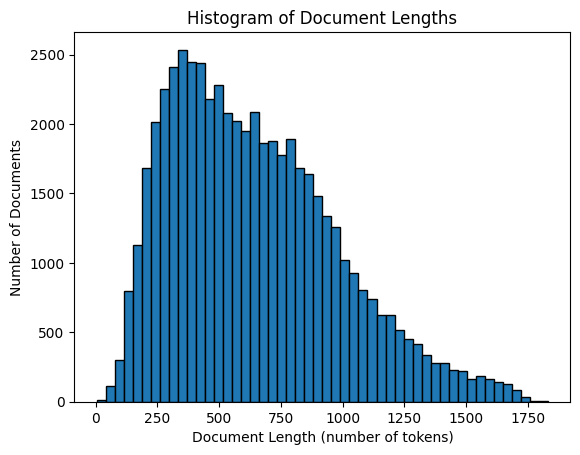

In [18]:
lengths = [len(doc) for doc in tokenized_articles]

plt.hist(lengths, bins=50, edgecolor = 'black')
plt.xlabel("Document Length (number of tokens)")
plt.ylabel("Number of Documents")
plt.title("Histogram of Document Lengths")
plt.show()

# After preprocessing

In [10]:
#nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def improved_filter(tokenized_doc):
  return [t.lemma_ for t in tokenized_doc if
          t.is_alpha and \
          not t.is_punct and \
          not t.is_space and \
          not t.is_stop and \
          t.pos_ in ['NOUN', 'VERB', 'ADJ']]

In [ ]:
%%time
#Tokenizing articles with advanced filtering -> more cleansed data
pre_tokenized_articles = list(map(improved_filter, nlp.pipe(dataset, batch_size = 512)))
pre_tokenized_articles = [doc for doc in pre_tokenized_articles if len(doc) != 0]

CPU times: user 32min 13s, sys: 1.89 s, total: 32min 15s
Wall time: 32min 23s


In [21]:
pre_N = len(pre_tokenized_articles)
print("Number of documents (N):", pre_N)

# Total tokens
pre_total_tokens = sum(len(doc) for doc in pre_tokenized_articles)
print("Total tokens:", pre_total_tokens)

# Vocabulary
pre_vocab = corpora.Dictionary(pre_tokenized_articles)
pre_V = len(pre_vocab)
print("Vocabulary size (|V|):", pre_V)

# Vocabulary after filtering extreme word
pre_vocab.filter_extremes(no_below=5, no_above=0.5)
pre_V = len(pre_vocab)
print("Vocabulary size after filtering extreme word (|V|):", pre_V)

# Document lengths
pre_lengths = [len(doc) for doc in pre_tokenized_articles if len(doc) != 0]

# Statistics
pre_avg_length = np.mean(pre_lengths)
pre_std_length = np.std(pre_lengths)
print("Average document length:", pre_avg_length)
print("Std document length:", pre_std_length)

Number of documents (N): 53926
Total tokens: 13435668
Vocabulary size (|V|): 55797
Vocabulary size after filtering extreme word (|V|): 25185
Average document length: 249.1500945740459
Std document length: 131.98504383335475


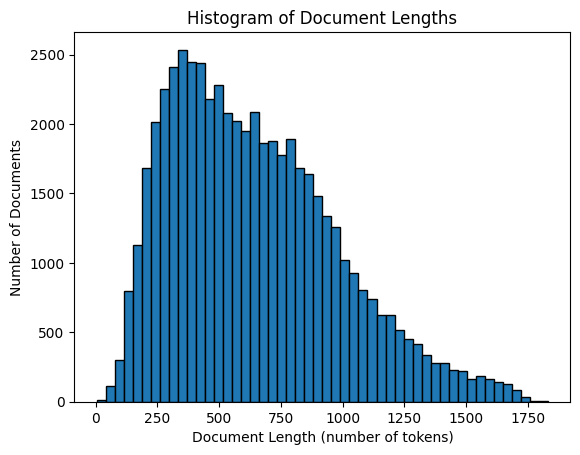

In [22]:
lengths = [len(doc) for doc in tokenized_articles]

plt.hist(lengths, bins=50, edgecolor = 'black')
plt.xlabel("Document Length (number of tokens)")
plt.ylabel("Number of Documents")
plt.title("Histogram of Document Lengths")
plt.show()

# Compare before and after

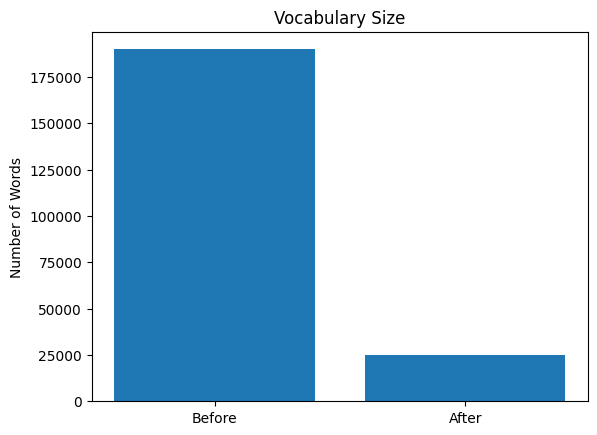

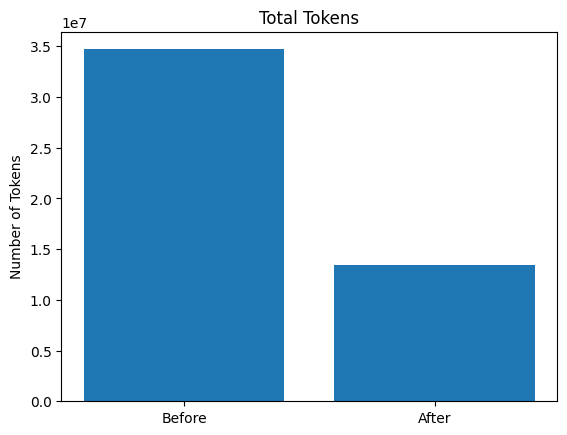

In [23]:
# Vocabulary
plt.bar(["Before","After"], [V, pre_V])
plt.title("Vocabulary Size")
plt.ylabel("Number of Words")
plt.show()

# Tokens
plt.bar(["Before","After"], [total_tokens, pre_total_tokens])
plt.title("Total Tokens")
plt.ylabel("Number of Tokens")
plt.show()

# Save preprocessed data

In [ ]:
import pickle
import os
os.makedirs("Dataset", exist_ok=True)
#Divided into train (80%), val (10%), test (10%)
N = len(pre_tokenized_articles)
train_end = int(0.8 * N)
val_end = int(0.9 * N)
train_articles = pre_tokenized_articles[:train_end]
val_articles = pre_tokenized_articles[train_end:val_end]
test_articles = pre_tokenized_articles[val_end:]

print(f"Split: train={len(train_articles)}, val={len(val_articles)}, test={len(test_articles)}")

#Save train,val,test dataset
with open('Dataset/train_data_for_LDA.pkl', 'wb') as f:
    pickle.dump(train_articles, f)
with open('Dataset/val_data_for_LDA.pkl', 'wb') as f:
    pickle.dump(val_articles, f)
with open('Dataset/test_data_for_LDA.pkl', 'wb') as f:
    pickle.dump(test_articles, f)
print("Đã lưu train/val/test dữ liệu cho LDA.")

Split: train=71912, val=8989, test=8989
Đã lưu train/val/test dữ liệu cho LDA.


In [ ]:
%%time
#pre_tokenized_articles = list(map(improved_filter, nlp.pipe(val_dataset, batch_size = 512)))
#pre_tokenized_articles = [doc for doc in pre_tokenized_articles if len(doc) != 0]

#with open('validation_data_for_LDA.pkl', 'wb') as f:
    #pickle.dump(pre_tokenized_articles, f)
#print(f"Processed and saved tokenized_articles to validation_data_for_LDA.pkl.")

Processed and saved tokenized_articles to validation_data_for_LDA.pkl.
CPU times: user 1.41 s, sys: 157 ms, total: 1.57 s
Wall time: 1.6 s


In [13]:
%%time
# Save preprocessed data for Trie

filename = 'Dataset/training_data_for_Trie.pkl'

# Lấy từ train_articles (đã là pre_tokenized, không trùng val/test của LDA)
trie_source = pre_tokenized_articles[:N-1]
#N = len(trie_source)
#test_size = int(0.1 * N)
#trie_test_articles = trie_source[:test_size]
#trie_train_articles = trie_source[test_size:]

with open(filename, 'wb') as f:
    pickle.dump(trie_source, f)
#with open('test_data_for_Trie.pkl', 'wb') as f:
    #pickle.dump(trie_test_articles, f)

print(f"Processed and saved trie_train={len(trie_source)}")

Processed and saved trie_train=89889
CPU times: user 7.63 s, sys: 1.06 s, total: 8.69 s
Wall time: 8.72 s


In [14]:
import os, pathlib, glob
print("cwd:", os.getcwd())
print("file in cwd:", glob.glob("*.pkl"))
print("file in Dataset:", glob.glob("Dataset/*.pkl"))
print("file in current root all:", glob.glob("**/*.pkl", recursive=True)[:20])

cwd: /content
file in cwd: []
file in Dataset: ['Dataset/train_data_for_LDA.pkl', 'Dataset/val_data_for_LDA.pkl', 'Dataset/test_data_for_LDA.pkl', 'Dataset/training_data_for_Trie.pkl']
file in current root all: ['Dataset/train_data_for_LDA.pkl', 'Dataset/val_data_for_LDA.pkl', 'Dataset/test_data_for_LDA.pkl', 'Dataset/training_data_for_Trie.pkl']


In [ ]:
%%time
# Save test data

#filename = 'test_data.pkl'

#test_tokenized_articles = list(map(improved_filter, nlp.pipe(test_dataset, batch_size = 512)))
#test_tokenized_articles = [doc for doc in test_tokenized_articles if len(doc) != 0]

#with open(filename, 'wb') as f:
    #pickle.dump(test_tokenized_articles, f)
#print(f"Processed and saved test_tokenized_articles to {filename}.")